# Solar Asset Health Check — Finding Underperforming Inverters

Goal: identify inverters that produce less than they should, and estimate the energy and money lost.

**Approach:**
1. Train a model that predicts how much AC power a **typical** inverter produces for given weather and time of day (*expected output*).
2. Compare each inverter's actual output with its expected output.
3. Rank inverters, flag the weak ones, and convert the shortfall into lost kWh and ₹.

**Why this works:** all ~22 inverters in a plant share the same weather sensor, so under identical conditions they should produce similar output. An inverter that keeps falling short points to a problem: a fault, dirty panels, or downtime.

AC power is used throughout. In Plant 1, DC power values appear to be recorded on a different scale (about 10× AC), while AC is consistent across both plants and is what reaches the grid.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

def load_plant(gen_file, weather_file, gen_date_format, plant_name):
    """Load one plant's generation + weather data and merge them on timestamp."""
    gen = pd.read_csv(f'../data/raw/solar/{gen_file}')
    weather = pd.read_csv(f'../data/raw/solar/{weather_file}')

    # Explicit date formats: Plant 1 generation uses DD-MM-YYYY; all other files use YYYY-MM-DD
    gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'], format=gen_date_format)
    weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')

    weather = weather[['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
    df = gen[['DATE_TIME', 'SOURCE_KEY', 'AC_POWER']].merge(weather, on='DATE_TIME', how='inner')
    df = df.rename(columns={'SOURCE_KEY': 'inverter'})
    df['plant'] = plant_name
    return df

plant1 = load_plant('Plant_1_Generation_Data.csv', 'Plant_1_Weather_Sensor_Data.csv', '%d-%m-%Y %H:%M', 'Plant 1')
plant2 = load_plant('Plant_2_Generation_Data.csv', 'Plant_2_Weather_Sensor_Data.csv', '%Y-%m-%d %H:%M:%S', 'Plant 2')
solar = pd.concat([plant1, plant2], ignore_index=True)

print('Total rows:', len(solar))
solar.groupby('plant').agg(
    rows=('AC_POWER', 'size'),
    inverters=('inverter', 'nunique'),
    start=('DATE_TIME', 'min'),
    end=('DATE_TIME', 'max')
)

Total rows: 136472


,rows,inverters,start,end
plant,,,,
Plant 1,68774,22,2020-05-15,2020-06-17 23:45:00
Plant 2,67698,22,2020-05-15,2020-06-17 23:45:00


## Keep Daylight Hours Only

At night every inverter produces 0, which tells us nothing about health. Very low irradiation at dawn and dusk is also excluded, because output is tiny and noisy then. Only rows with irradiation above 0.05 are kept.

A decimal **hour of day** feature (e.g. 14:30 → 14.5) is added, since the sun's angle affects output even at the same irradiation.

In [2]:
solar['hour'] = solar['DATE_TIME'].dt.hour + solar['DATE_TIME'].dt.minute / 60

day = solar[solar['IRRADIATION'] > 0.05].copy()
print(f'Daylight rows kept: {len(day)} of {len(solar)} ({len(day) / len(solar):.0%})')

Daylight rows kept: 64892 of 136472 (48%)


## Expected-Output Model (One per Plant)

An XGBoost model per plant predicts AC power from **irradiation, ambient temperature, module temperature, and hour of day**.

Three design choices matter:

1. **The inverter ID is deliberately *not* a feature.** If it were, the model would learn that a weak inverter is "supposed" to be weak, and the problem would disappear from the residuals. Without it, the model can only learn what a *typical* inverter produces.
2. **Absolute-error objective:** the model predicts the **median** inverter rather than the average, so a few broken inverters (or outages at 0) don't drag down "expected" output for everyone.
3. **Held-out check:** each model is trained on days up to 7 June and tested on the remaining days, to confirm that weather really explains output before the model is used as a yardstick.

In [3]:
FEATURES = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'hour']
SPLIT_DATE = '2020-06-08'

models = {}
eval_rows = []

for plant, df in day.groupby('plant'):
    train = df[df['DATE_TIME'] < SPLIT_DATE]
    held_out = df[df['DATE_TIME'] >= SPLIT_DATE]

    model = XGBRegressor(
        objective='reg:absoluteerror',   # predict the median inverter, robust to faulty ones
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
    model.fit(train[FEATURES], train['AC_POWER'])
    models[plant] = model

    pred = np.clip(model.predict(held_out[FEATURES]), 0, None)
    eval_rows.append({
        'Plant': plant,
        'Train rows': len(train),
        'Held-out rows': len(held_out),
        'Held-out MAE (kW)': round(mean_absolute_error(held_out['AC_POWER'], pred), 1),
        'Mean AC power (kW)': round(held_out['AC_POWER'].mean(), 1),
        'Held-out R²': round(r2_score(held_out['AC_POWER'], pred), 3)
    })

pd.DataFrame(eval_rows)

,Plant,Train rows,Held-out rows,Held-out MAE (kW),Mean AC power (kW),Held-out R²
0,Plant 1,23300,9966,34.3,601.6,0.955
1,Plant 2,21660,9966,139.8,441.8,0.174


## Inverter Scorecard

For every inverter, across all daylight readings:

- **Performance ratio** = actual energy ÷ expected energy. Around 1.0 means typical; 0.90 means it produced 10% less than expected.
- **Lost energy (kWh)** = expected − actual (0 if the inverter did better than expected).
- **Downtime (hours)** = time the inverter produced exactly 0 while the model expected more than 50 kW, i.e. it was offline in good sunlight.
- **Flag:** inverters with a performance ratio below **0.95** are marked **Check**.

Readings are every 15 minutes, so each reading counts for 0.25 hours when converting kW to kWh.

In [4]:
INTERVAL_HOURS = 0.25        # 15-minute readings
DOWNTIME_EXPECTED_KW = 50    # "offline" = 0 output while the model expected more than this
FLAG_THRESHOLD = 0.95        # performance ratio below this -> flagged

# Expected output for every daylight reading, using that plant's model
day['expected'] = 0.0
for plant, model in models.items():
    mask = day['plant'] == plant
    day.loc[mask, 'expected'] = np.clip(model.predict(day.loc[mask, FEATURES]), 0, None)

day['actual_kwh'] = day['AC_POWER'] * INTERVAL_HOURS
day['expected_kwh'] = day['expected'] * INTERVAL_HOURS
day['downtime_h'] = ((day['AC_POWER'] == 0) & (day['expected'] > DOWNTIME_EXPECTED_KW)) * INTERVAL_HOURS

scorecard = day.groupby(['plant', 'inverter'])[['actual_kwh', 'expected_kwh', 'downtime_h']].sum()
scorecard['performance_ratio'] = scorecard['actual_kwh'] / scorecard['expected_kwh']
scorecard['lost_kwh'] = (scorecard['expected_kwh'] - scorecard['actual_kwh']).clip(lower=0)
scorecard['status'] = np.where(scorecard['performance_ratio'] < FLAG_THRESHOLD, 'Check', 'OK')

scorecard = scorecard.sort_values('performance_ratio')
print('Inverters flagged:', (scorecard['status'] == 'Check').sum(), 'of', len(scorecard))
scorecard.round({'actual_kwh': 0, 'expected_kwh': 0, 'downtime_h': 1, 'performance_ratio': 3, 'lost_kwh': 0}).head(10)

Inverters flagged: 19 of 44


actual_kwh  expected_kwh  downtime_h  \
plant   inverter                                                
Plant 2 Quc1TzYxW2pYoWX    134272.0      228387.0        69.5   
        Et9kgGMDl729KT4    145778.0      228387.0        76.0   
        LYwnQax7tkwH5Cb    155050.0      233219.0        79.2   
        rrq4fwE8jgrTyWY    165317.0      233219.0        66.8   
        q49J1IKaHRwDQnt    178779.0      233219.0        59.5   
        81aHJ1q11NBPMrL    182470.0      233219.0        64.8   
        xoJJ8DcxJEcupym    190475.0      233219.0        50.8   
        9kRcWv60rDACzjR    193423.0      233219.0        51.5   
        WcxssY2VbP4hApt    193953.0      233219.0        53.5   
        LlT2YUhhzqhg5Sw    194125.0      233219.0        49.5   

                         performance_ratio  lost_kwh status  
plant   inverter                                             
Plant 2 Quc1TzYxW2pYoWX              0.588   94114.0  Check  
        Et9kgGMDl729KT4              0.638   82608.0  Check  
        LYwnQax7tkwH5Cb              0.665   78169.0  Check  
        rrq4fwE8jgrTyWY              0.709   67901.0  Check  
        q49J1IKaHRwDQnt              0.767   54440.0  Check  
        81aHJ1q11NBPMrL              0.782   50748.0  Check  
        xoJJ8DcxJEcupym              0.817   42743.0  Check  
        9kRcWv60rDACzjR              0.829   39795.0  Check  
        WcxssY2VbP4hApt              0.832   39266.0  Check  
        LlT2YUhhzqhg5Sw              0.832   39093.0  Check

## Estimated Cost of Underperformance

Lost energy is converted into money using an **assumed tariff of ₹3 per kWh** (a typical order of magnitude for utility-scale solar in India; change `TARIFF_RS_PER_KWH` to test other values).

The **annualised** figure scales the loss in this ~34-day window to a full year. It's an indicative "if nothing is fixed" estimate, not a forecast, because it assumes the same weather and the same faults all year.

In [5]:
TARIFF_RS_PER_KWH = 3.0   # assumption: ₹ per kWh
n_days = solar['DATE_TIME'].dt.date.nunique()

scorecard['lost_rs'] = scorecard['lost_kwh'] * TARIFF_RS_PER_KWH
scorecard['lost_rs_per_year'] = scorecard['lost_rs'] * 365 / n_days

flagged = scorecard[scorecard['status'] == 'Check']

print(f'Data window: {n_days} days | Tariff assumption: ₹{TARIFF_RS_PER_KWH}/kWh')
print(f'Flagged inverters — lost energy in window: {flagged["lost_kwh"].sum():,.0f} kWh')
print(f'Flagged inverters — estimated loss in window: ₹{flagged["lost_rs"].sum():,.0f}')
print(f'Flagged inverters — annualised estimate: ₹{flagged["lost_rs_per_year"].sum():,.0f} per year')

flagged[['performance_ratio', 'lost_kwh', 'downtime_h', 'lost_rs', 'lost_rs_per_year']].round(
    {'performance_ratio': 3, 'lost_kwh': 0, 'downtime_h': 1, 'lost_rs': 0, 'lost_rs_per_year': 0})

Data window: 34 days | Tariff assumption: ₹3.0/kWh
Flagged inverters — lost energy in window: 789,595 kWh
Flagged inverters — estimated loss in window: ₹2,368,786
Flagged inverters — annualised estimate: ₹25,429,611 per year


performance_ratio  lost_kwh  downtime_h   lost_rs  \
plant   inverter                                                             
Plant 2 Quc1TzYxW2pYoWX              0.588   94114.0        69.5  282343.0   
        Et9kgGMDl729KT4              0.638   82608.0        76.0  247825.0   
        LYwnQax7tkwH5Cb              0.665   78169.0        79.2  234506.0   
        rrq4fwE8jgrTyWY              0.709   67901.0        66.8  203704.0   
        q49J1IKaHRwDQnt              0.767   54440.0        59.5  163320.0   
        81aHJ1q11NBPMrL              0.782   50748.0        64.8  152245.0   
        xoJJ8DcxJEcupym              0.817   42743.0        50.8  128230.0   
        9kRcWv60rDACzjR              0.829   39795.0        51.5  119386.0   
        WcxssY2VbP4hApt              0.832   39266.0        53.5  117798.0   
        LlT2YUhhzqhg5Sw              0.832   39093.0        49.5  117280.0   
        PeE6FRyGXUgsRhN              0.843   36543.0        44.5  109630.0   
        oZZkBaNadn6DNKz              0.868   30851.0        44.5   92554.0   
        vOuJvMaM2sgwLmb              0.888   26035.0        41.2   78106.0   
        V94E5Ben1TlhnDV              0.889   25873.0        42.2   77618.0   
Plant 1 bvBOhCH3iADSZry              0.904   22972.0         5.0   68916.0   
        1BY6WEcLGh8j5v7              0.918   19637.0         4.8   58911.0   
Plant 2 oZ35aAeoifZaQzV              0.940   13593.0        33.2   40778.0   
        4UPUqMRk7TRMgml              0.943   13005.0        31.0   39014.0   
        Qf4GUc1pJu5T6c6              0.947   12207.0        30.5   36622.0   

                         lost_rs_per_year  
plant   inverter                           
Plant 2 Quc1TzYxW2pYoWX         3031035.0  
        Et9kgGMDl729KT4         2660472.0  
        LYwnQax7tkwH5Cb         2517490.0  
        rrq4fwE8jgrTyWY         2186818.0  
        q49J1IKaHRwDQnt         1753288.0  
        81aHJ1q11NBPMrL         1634400.0  
        xoJJ8DcxJEcupym         1376588.0  
        9kRcWv60rDACzjR         1281648.0  
        WcxssY2VbP4hApt         1264591.0  
        LlT2YUhhzqhg5Sw         1259037.0  
        PeE6FRyGXUgsRhN         1176909.0  
        oZZkBaNadn6DNKz          993596.0  
        vOuJvMaM2sgwLmb          838492.0  
        V94E5Ben1TlhnDV          833256.0  
Plant 1 bvBOhCH3iADSZry          739837.0  
        1BY6WEcLGh8j5v7          632426.0  
Plant 2 oZ35aAeoifZaQzV          437759.0  
        4UPUqMRk7TRMgml          418823.0  
        Qf4GUc1pJu5T6c6          393149.0

## Inverter Performance at a Glance

Each dot is one inverter. The solid line at 1.0 is typical performance; the dashed line is the 0.95 flag threshold. Dots are used instead of bars because all values sit close to 1.0, and bars (which must start at 0) would hide the differences.

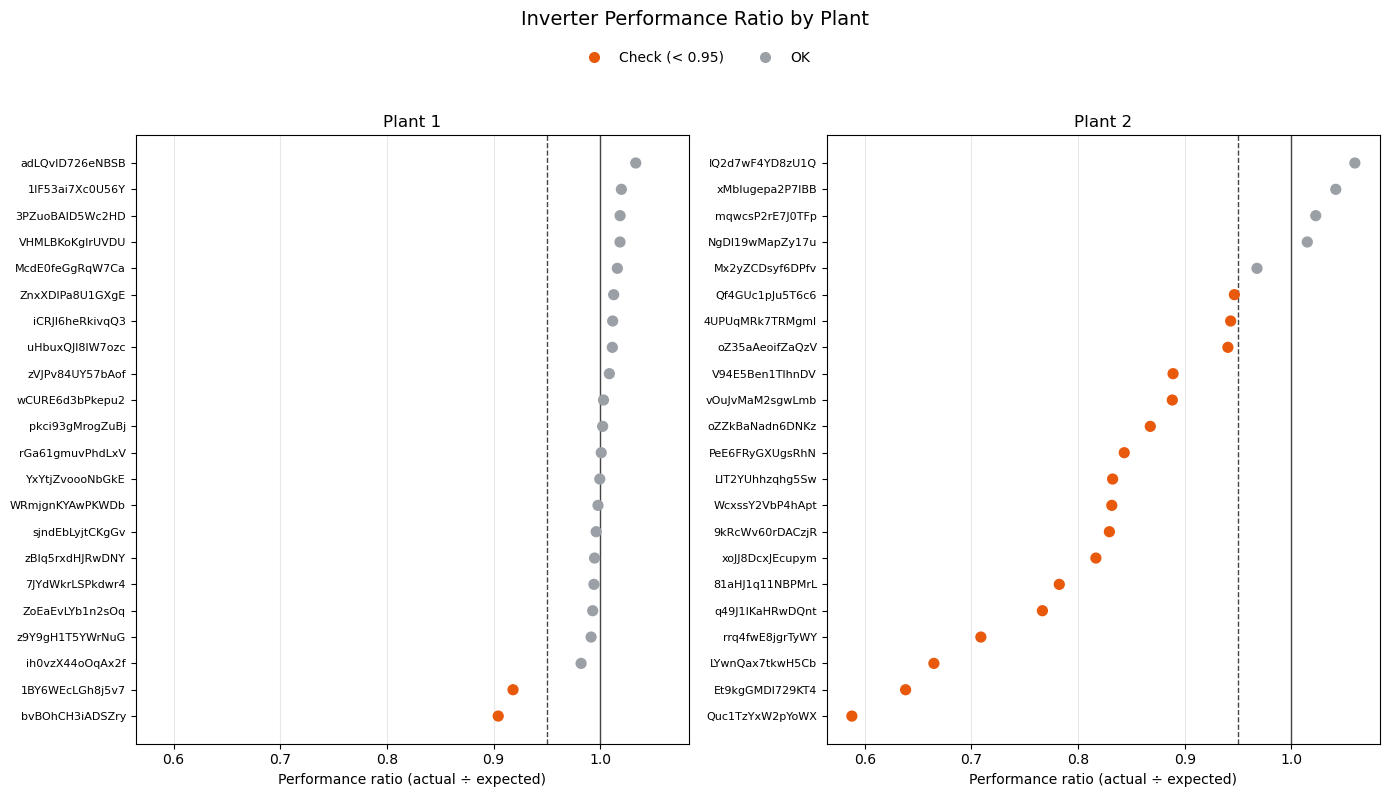

In [16]:
from matplotlib.lines import Line2D

OK_COLOR = '#9aa0a6'      # muted gray for normal inverters
FLAG_COLOR = '#e8590c'    # single accent colour for flagged inverters

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharex=True)

for ax, (plant, group) in zip(axes, scorecard.groupby(level='plant')):
    group = group.sort_values('performance_ratio')
    labels = group.index.get_level_values('inverter')
    colors = np.where(group['status'] == 'Check', FLAG_COLOR, OK_COLOR)

    ax.scatter(group['performance_ratio'], range(len(group)), c=colors, s=50, zorder=3)
    ax.axvline(1.0, color='#444444', linewidth=1)
    ax.axvline(FLAG_THRESHOLD, color='#444444', linewidth=1, linestyle='--')
    ax.set_yticks(range(len(group)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(plant)
    ax.set_xlabel('Performance ratio (actual ÷ expected)')
    ax.grid(axis='x', alpha=0.3)

legend_items = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=FLAG_COLOR, markersize=9, label=f'Check (< {FLAG_THRESHOLD})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=OK_COLOR, markersize=9, label='OK'),
]

# Title at the very top, legend just below it, plots below both
fig.suptitle('Inverter Performance Ratio by Plant', y=0.99, fontsize=14)
fig.legend(handles=legend_items, loc='upper center', bbox_to_anchor=(0.5, 0.955), ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.92])   # reserve the top 8% of the figure for title + legend
fig.savefig('../images/solar_performance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## Closer Look: Worst Inverter

Actual vs. expected output for the lowest-ranked inverter over its last 3 days of data. Gaps are night-time.

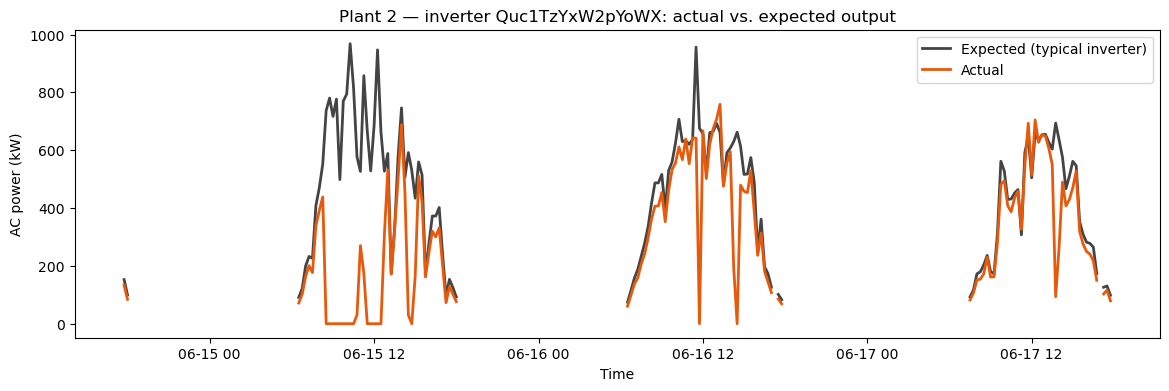

In [17]:
worst_plant, worst_inverter = scorecard.index[0]

w = day[(day['plant'] == worst_plant) & (day['inverter'] == worst_inverter)]
w = w.set_index('DATE_TIME')[['AC_POWER', 'expected']]
w = w[w.index >= w.index.max() - pd.Timedelta(days=3)]
w = w.asfreq('15min')   # inserts empty rows at night so lines break instead of joining across nights

plt.figure(figsize=(14, 4))
plt.plot(w.index, w['expected'], label='Expected (typical inverter)', linewidth=2, color='#444444')
plt.plot(w.index, w['AC_POWER'], label='Actual', linewidth=2, color=FLAG_COLOR)
plt.title(f'{worst_plant} — inverter {worst_inverter}: actual vs. expected output')
plt.xlabel('Time')
plt.ylabel('AC power (kW)')
plt.legend()
plt.show()

## Sanity Check: Does a Model-Free Method Agree?

With no labelled faults to check against, the ranking is cross-checked with a simple method that uses no model at all: compare each inverter with the **median of all inverters in the same plant at the same moment**.

If both methods rank the inverters similarly (Spearman rank correlation close to 1), the model's findings aren't an artefact of the model.

In [18]:
# Peer median: the middle value of all inverters in the same plant at the same timestamp
day['peer_median'] = day.groupby(['plant', 'DATE_TIME'])['AC_POWER'].transform('median')

peer = day.groupby(['plant', 'inverter'])[['AC_POWER', 'peer_median']].sum()
scorecard['peer_ratio'] = peer['AC_POWER'] / peer['peer_median']

rho = scorecard['performance_ratio'].corr(scorecard['peer_ratio'], method='spearman')
print(f'Spearman rank correlation (model ratio vs. peer ratio): {rho:.3f}')

Spearman rank correlation (model ratio vs. peer ratio): 0.971


## Why Is Plant 2's R² Low?

Plant 1's model explains output well (held-out R² 0.955), but Plant 2's scored only 0.174. Two explanations are possible:

1. **Outages lower the score:** during zero-output periods the model correctly predicts normal output, but the inverter reports 0. Weather can't predict an outage, so these count as large errors.
2. **The weather sensor doesn't represent the panels well**, which would make the model a weak yardstick for Plant 2.

To separate them, the model is also scored against the **peer median** (what a typical, working inverter produced at each moment). A high R² against the peer median points to explanation 1.

In [19]:
diagnostic = []
for plant, df in day.groupby('plant'):
    held_out = df[df['DATE_TIME'] >= SPLIT_DATE]

    # One row per timestamp: the typical inverter's actual output vs. the model's expected output
    # (expected is identical for all inverters in a plant at a given moment, so 'first' is safe)
    per_time = held_out.groupby('DATE_TIME').agg(
        peer_median=('AC_POWER', 'median'),
        expected=('expected', 'first')
    )

    diagnostic.append({
        'Plant': plant,
        'R² vs. individual inverters': round(r2_score(held_out['AC_POWER'], held_out['expected']), 3),
        'R² vs. peer median': round(r2_score(per_time['peer_median'], per_time['expected']), 3),
        'Share of daylight readings offline': f"{(df['downtime_h'] > 0).mean():.1%}"
    })

pd.DataFrame(diagnostic)

,Plant,R² vs. individual inverters,R² vs. peer median,Share of daylight readings offline
0,Plant 1,0.955,0.99,0.2%
1,Plant 2,0.174,0.79,11.9%


## Save Outputs

The scorecard and plant models are saved for the Streamlit dashboard.

In [22]:
scorecard.to_csv('../data/processed/solar_scorecard.csv')

for plant, model in models.items():
    model.save_model(f'../models/solar_expected_{plant.replace(" ", "_").lower()}.json')

print('Saved scorecard and plant models.')

Saved scorecard and plant models.


## Save Daily Summary for the Dashboard

Daily actual vs. expected energy for each inverter, used by the dashboard's inverter detail chart.

In [21]:
daily = (
    day.assign(date=day['DATE_TIME'].dt.date)
       .groupby(['plant', 'inverter', 'date'])[['actual_kwh', 'expected_kwh', 'downtime_h']]
       .sum()
       .reset_index()
)
daily.to_csv('../data/processed/solar_daily.csv', index=False)
print('Saved daily summary:', daily.shape)

Saved daily summary: (1464, 6)


## Results & Conclusions

**Model quality (held-out days, 8–17 June):**

| Plant | R² vs. individual inverters | R² vs. peer median | Daylight readings offline |
|---|---|---|---|
| Plant 1 | 0.955 | 0.99 | 0.2% |
| Plant 2 | 0.174 | 0.79 | 11.9% |

**Key findings:**
1. **Plant 1 is healthy.** Weather explains its output almost perfectly, and only **2 of 22 inverters** are flagged (performance ratio ≈ 0.91–0.92). Recommendation: inspect those two.
2. **Plant 2 has a plant-wide problem.** **17 of 22 inverters** are flagged (performance ratio 0.59–0.95). The worst were at zero output for 50–80 hours of good sunlight in 34 days, and Plant 2's inverters were offline about 60× more often than Plant 1's. When most inverters share the same pattern, a plant-level cause (grid trips, curtailment, communication or logging failures) is more likely than many separate faults. Recommendation: **investigate Plant 2 as a whole first.**
3. **The low R² in Plant 2 is mainly caused by outages, not a broken model.** Scored against the peer median, R² rises from 0.17 to 0.79. The yardstick is still less precise than Plant 1's, so Plant 2's loss figures are indicative.
4. **Two independent methods agree.** The model-based ranking and a model-free peer comparison have a Spearman rank correlation of **0.971**.

**Estimated impact of flagged inverters** (tariff assumption ₹3/kWh):
- Lost energy over the 34-day window: **~790,000 kWh**
- Estimated loss in the window: **~₹23.7 lakh**
- Annualised, if nothing is fixed: **~₹2.5 crore per year** (indicative only, since it assumes the same weather and faults all year)

**Limitations:**
- From the data alone, a real outage can't be distinguished from a logger recording 0, so these are reported as *zero-output periods*.
- Loss estimates depend on the tariff assumption and on the less precise Plant 2 yardstick.
- Only 34 days of data, so no seasonal patterns.